# MLflow tutorial

PyTorch integration

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import mlflow
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from numpy.typing import NDArray


# MLflow config
# mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('PyTorch-MLflow experiment')

mlflow.config.enable_system_metrics_logging()
mlflow.config.set_system_metrics_sampling_interval(1)

# PyTorch config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f'CUDA version: {torch.version.cuda}')

CUDA version: 13.0


In [2]:
def to_numpy(t: torch.Tensor) -> NDArray:
    '''Converts a tensor to a numpy array on the CPU'''
    return t.cpu().numpy()

## Data import and organization

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081))
])

train_dataset  = datasets.FashionMNIST('data', train=True, transform=transform)
test_dataset  = datasets.FashionMNIST('data', train=False, transform=transform)
clothing_types = [
    'top', 'trouser', 'pullover', 'dress', 'coat',
    'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot'
]

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    pin_memory=True
)

### Data exploration

In [4]:
batch, labels = next(iter(test_loader))

print(f'{len(train_loader) = }')
print(f'{len(test_loader) = }')
print(f'{batch.shape = }')
print(f'{labels.shape = }')

len(train_loader) = 938
len(test_loader) = 157
batch.shape = torch.Size([64, 1, 28, 28])
labels.shape = torch.Size([64])


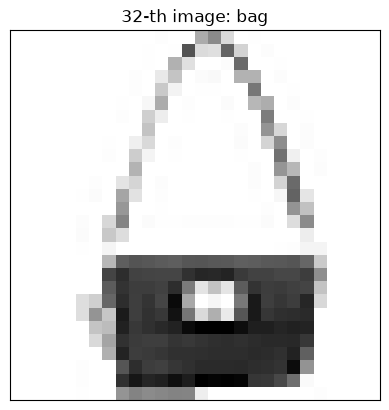

In [5]:
n = 31
im = to_numpy(batch[n, 0, :, :])
clothing_type = clothing_types[labels[n]]

fig, ax = plt.subplots()
ax.imshow(im, cmap='Greys')

ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f'{n+1}-th image: {clothing_type}')

plt.show()

## Model, parameters, and training

In [6]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.relu_stack(x)
        return logits

model: MLP = MLP().to(device)


params = {
    'epochs': 5,
    'learning_rate': 1e-3,
    'batch_size': 64,
    'optimizer': 'SGD',
    'model_type': 'MLP',
    'hidden_units': [512, 512]
}

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=params['learning_rate'])

In [7]:
with mlflow.start_run() as run:
    mlflow.log_params(params)

    for epoch in tqdm(range(params['epochs'])):
        model.train()
        train_loss, correct, total = 0, 0, 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            # Forward pass
            optimizer.zero_grad()
            output = model(data)
            loss = loss_fn(output, target)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Metrics
            train_loss += loss.item()
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

            # Log batch metrics (every 100 batches)
            if batch_idx % 100 == 0:
                batch_loss = train_loss / (batch_idx + 1)
                batch_acc = 100.0 * correct / total
                mlflow.log_metrics(
                    {"batch_loss": batch_loss, "batch_accuracy": batch_acc},
                    step=epoch * len(train_loader) + batch_idx,
                )
            
        # Calculate epoch metrics
        epoch_loss = train_loss / len(train_loader)
        epoch_acc = 100.0 * correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = loss_fn(output, target)

                val_loss += loss.item()
                _, predicted = output.max(1)
                val_total += target.size(0)
                val_correct += predicted.eq(target).sum().item()

        # Calculate and log epoch validation metrics
        val_loss = val_loss / len(test_loader)
        val_acc = 100.0 * val_correct / val_total

        # Log epoch metrics
        mlflow.log_metrics(
            {
                "train_loss": epoch_loss,
                "train_accuracy": epoch_acc,
                "val_loss": val_loss,
                "val_accuracy": val_acc,
            },
            step=epoch,
        )
        # Log checkpoint at the end of each epoch
        mlflow.pytorch.log_model(model, name=f"checkpoint_{epoch}", serialization_format='pickle')

        print(
            f"Epoch {epoch + 1}/{params['epochs']}, "
            f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%, "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%"
        )

    # Log the final trained model
    model_info = mlflow.pytorch.log_model(model, name="final_model", serialization_format='pickle')

2026/09/07 17:11:33 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/09/07 17:11:33 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
 20%|██        | 1/5 [00:08<00:34,  8.66s/it]

Epoch 1/5, Train Loss: 1.7975, Train Acc: 52.38%, Val Loss: 1.2923, Val Acc: 64.61%


2026/09/07 17:11:46 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
 40%|████      | 2/5 [00:16<00:24,  8.24s/it]

Epoch 2/5, Train Loss: 1.0405, Train Acc: 67.74%, Val Loss: 0.8961, Val Acc: 69.80%


2026/09/07 17:11:54 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
 60%|██████    | 3/5 [00:24<00:16,  8.04s/it]

...

2026/09/07 17:12:02 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
 80%|████████  | 4/5 [00:32<00:07,  7.94s/it]

Epoch 4/5, Train Loss: 0.7209, Train Acc: 75.41%, Val Loss: 0.6991, Val Acc: 75.63%


2026/09/07 17:12:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
100%|██████████| 5/5 [00:40<00:00,  8.04s/it]
2026/09/07 17:12:14 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch 5/5, Train Loss: 0.6595, Train Acc: 77.56%, Val Loss: 0.6468, Val Acc: 77.53%


2026/09/07 17:12:17 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/09/07 17:12:17 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


In [26]:
id_run = run.info.run_id

## Inference and evaluation

In [27]:
# Load the final model
model = mlflow.pytorch.load_model(f"runs:/{id_run}/final_model")
# or load a checkpoint
# model = mlflow.pytorch.load_model("runs:/<run_id>/checkpoint_<epoch>")
model.to(device)
model.eval()

# Resume the previous run to log test metrics
with mlflow.start_run(run_id=run.info.run_id) as run:
    # Evaluate the model on the test set
    test_loss, test_correct, test_total = 0, 0, 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = loss_fn(output, target)

            test_loss += loss.item()
            _, predicted = output.max(1)
            test_total += target.size(0)
            test_correct += predicted.eq(target).sum().item()

    # Calculate and log final test metrics
    test_loss = test_loss / len(test_loader)
    test_acc = 100.0 * test_correct / test_total

    mlflow.log_metrics({"test_loss": test_loss, "test_accuracy": test_acc})
    print(f"Final Test Accuracy: {test_acc:.2f}%")

2026/09/07 17:23:16 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/09/07 17:23:16 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2026/09/07 17:23:17 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/09/07 17:23:17 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


Final Test Accuracy: 77.53%
